In [5]:
# Load the training and testing datasets
train_df = pd.read_csv('./train_data.csv') 
test_df = pd.read_csv('./test_data.csv')  

# Check the column names
print("Train Data Columns:", train_df.columns)
print("Test Data Columns:", test_df.columns)

Train Data Columns: Index(['Tweet', 'Sentiment_Label'], dtype='object')
Test Data Columns: Index(['Tweet', 'Sentiment_Label'], dtype='object')


In [11]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder

# Load the training and testing datasets
train_df = pd.read_csv('train_data.csv')  
test_df = pd.read_csv('test_data.csv')  

# Preprocess the data 
train_df = train_df.dropna(subset=['Tweet'])  # Drop rows with missing text
test_df = test_df.dropna(subset=['Tweet'])  # Drop rows with missing text
train_df = train_df.drop_duplicates(subset=['Tweet'])  # Drop duplicate rows
test_df = test_df.drop_duplicates(subset=['Tweet'])  # Drop duplicate rows

In [13]:
# Use a smaller subset for quick testing (optional)
train_df = train_df.sample(frac=0.1, random_state=42)
test_df = test_df.sample(frac=0.1, random_state=42)

# Encode labels
le = LabelEncoder()
train_df['Sentiment_Label'] = le.fit_transform(train_df['Sentiment_Label'])
test_df['Sentiment_Label'] = le.transform(test_df['Sentiment_Label']) 

# Vectorize the text using TF-IDF with unigrams and bigrams
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2)) 
X_train = vectorizer.fit_transform(train_df['Tweet']).toarray()  
X_test = vectorizer.transform(test_df['Tweet']).toarray()  
y_train = train_df['Sentiment_Label'].values
y_test = test_df['Sentiment_Label'].values

In [15]:
# Define the RNN model
model = Sequential()
model.add(SimpleRNN(units=64, activation='tanh', input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Dropout to prevent overfitting
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # Adjust the number of output neurons based on your label classes

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Reshape input data for RNN (samples, timesteps, features)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Train the model
history = model.fit(X_train_rnn, y_train, epochs=10, batch_size=64, validation_data=(X_test_rnn, y_test))

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_rnn, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/10


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 839ms/step - accuracy: 0.3318 - loss: 1.1130 - val_accuracy: 0.3367 - val_loss: 1.0990
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 805ms/step - accuracy: 0.3325 - loss: 1.1085 - val_accuracy: 0.3117 - val_loss: 1.1035
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 832ms/step - accuracy: 0.3630 - loss: 1.1070 - val_accuracy: 0.3383 - val_loss: 1.1004
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 821ms/step - accuracy: 0.3526 - loss: 1.1074 - val_accuracy: 0.3500 - val_loss: 1.0965
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 822ms/step - accuracy: 0.3185 - loss: 1.1227 - val_accuracy: 0.3717 - val_loss: 1.0954
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 842ms/step - accuracy: 0.3386 - loss: 1.1217 - val_accuracy: 0.3400 - val_loss: 1.1109
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 841ms/step - accuracy: 0.3459 - loss: 1.1286 - val_accuracy: 0.3367 - val_loss: 1.1045
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 846ms/step - accuracy: 0.3281 - loss: 1.1323 - val_accuracy: 0.295

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step


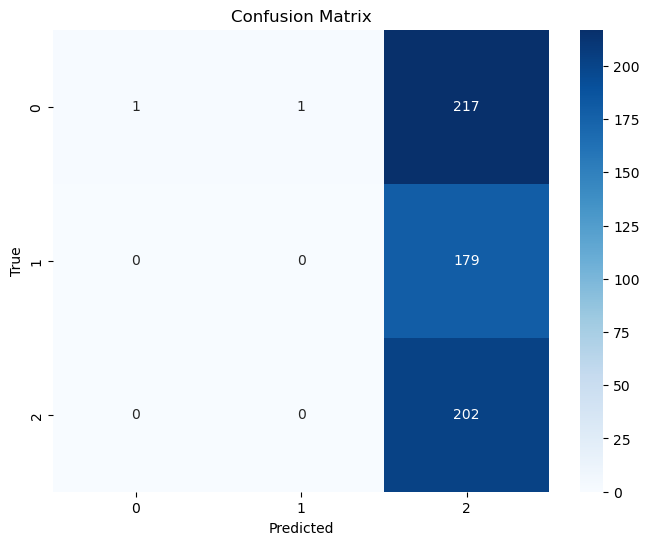

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.00      0.01       219
     neutral       0.00      0.00      0.00       179
    positive       0.34      1.00      0.51       202

    accuracy                           0.34       600
   macro avg       0.45      0.33      0.17       600
weighted avg       0.48      0.34      0.17       600

AUC Score: 0.5229


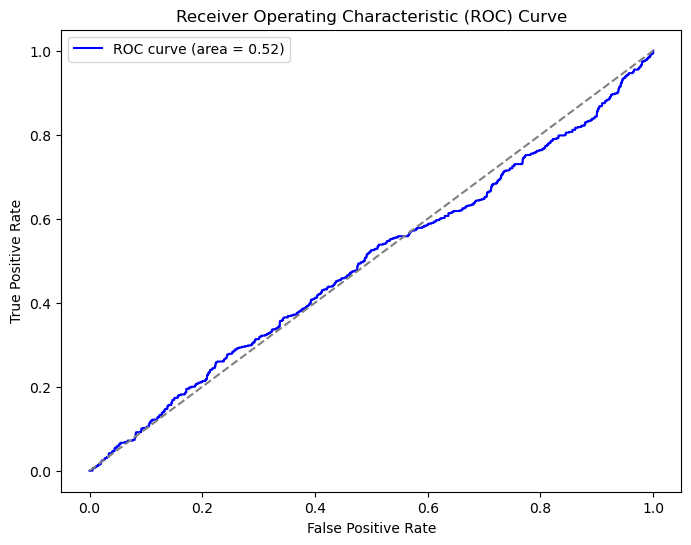

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.metrics import AUC

# Predict the labels for the test data
y_pred_probs = model.predict(X_test_rnn)  
y_pred = np.argmax(y_pred_probs, axis=1)  

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using Matplotlib and Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Define the class names manually (ensure they match your labels)
class_names = ['negative', 'neutral', 'positive']  # Replace with your actual class names

# Print classification report with the correct class names
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Compute and display the AUC score (One vs Rest for multi-class classification)
# We need to binarize the true labels for multi-class classification AUC
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
auc = roc_auc_score(y_test_bin, y_pred_probs, average='macro', multi_class='ovr')

print(f"AUC Score: {auc:.4f}")

# Plot ROC Curve for each class (Optional for multi-class)
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_probs.ravel())
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='best')
plt.show()

## HyperParameter Tuning

In [104]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model-building function
def build_model(units=64, dropout_rate=0.2, optimizer='adam', rnn_type='SimpleRNN'):
    model = Sequential()

    # Choose between RNN types
    if rnn_type == 'SimpleRNN':
        model.add(SimpleRNN(units=units, activation='tanh', input_shape=(X_train.shape[1], 1)))
    elif rnn_type == 'GRU':
        model.add(GRU(units=units, activation='tanh', input_shape=(X_train.shape[1], 1)))
    else:  # Bidirectional RNN
        model.add(Bidirectional(SimpleRNN(units=units, activation='tanh', return_sequences=True), input_shape=(X_train.shape[1], 1)))
    
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))  # Adjust number of classes based on your labels
    
    # Compile the model
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [108]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Wrap the model in KerasClassifier, passing rnn_type directly in the constructor
model = KerasClassifier(model=build_model, dropout_rate=0.2, rnn_type='SimpleRNN', units=64, verbose=1)

# Define the hyperparameter grid for tuning (without rnn_type)
param_grid = {
    'optimizer': ['adam'],  # Optimizer choices
    'batch_size': [32],  # Batch size
    'epochs': [5]  # Number of epochs
}

# Create GridSearchCV with the parameter grid
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)

# Fit the grid search to the data (use one-hot encoded labels)
grid_result = grid_search.fit(X_train_rnn, y_train_onehot)

# Print the best result
print(f"Best Hyperparameters: {grid_result.best_params_}")
print(f"Best Score: {grid_result.best_score_}")

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 549ms/step - accuracy: 0.3462 - loss: 1.1128
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 541ms/step - accuracy: 0.3452 - loss: 1.1100
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 551ms/step - accuracy: 0.3127 - loss: 1.1186
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 43s 570ms/step - accuracy: 0.3287 - loss: 1.1137
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 563ms/step - accuracy: 0.3258 - loss: 1.1103
Best Hyperparameters: {'batch_size': 32, 'epochs': 5, 'optimizer': 'adam'}
Best Score: 0.3297137046307885


Best Hyperparameters: {'batch_size': 32, 'epochs': 5, 'optimizer': 'adam'}
Best AUC Score: 0.3297137046307885
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step


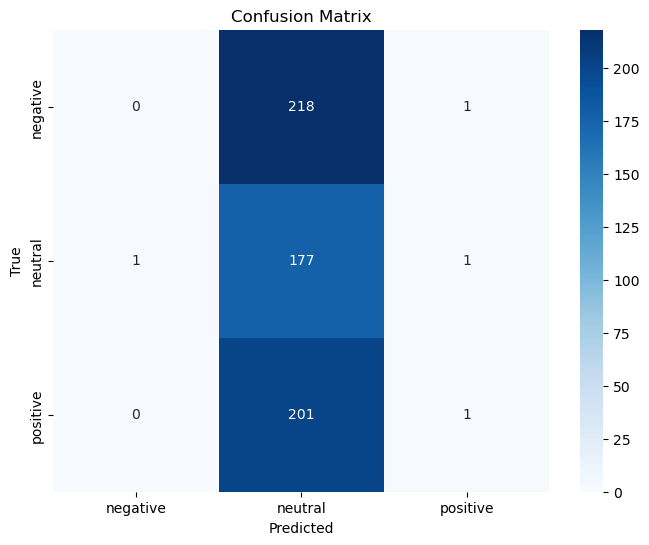

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       219
     neutral       0.30      0.99      0.46       179
    positive       0.33      0.00      0.01       202

    accuracy                           0.30       600
   macro avg       0.21      0.33      0.16       600
weighted avg       0.20      0.30      0.14       600

AUC Score: 0.4985


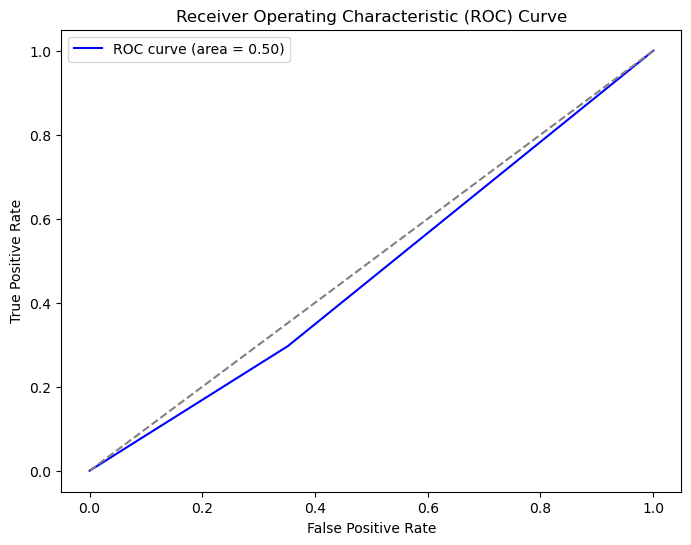

In [110]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Retrieve the best model from the grid search
best_model = grid_result.best_estimator_

# Print the best parameters and best AUC score
print(f"Best Hyperparameters: {grid_result.best_params_}")
print(f"Best AUC Score: {grid_result.best_score_}")

# Predict the labels for the test data
y_pred_probs = best_model.predict(X_test_rnn)  # Get the predicted probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class labels

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using Matplotlib and Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'], ax=ax)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print classification report (precision, recall, f1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

# Compute and display the AUC score (One vs Rest for multi-class classification)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Adjust according to your classes
auc = roc_auc_score(y_test_bin, y_pred_probs, average='macro', multi_class='ovr')
print(f"AUC Score: {auc:.4f}")

# Plot ROC Curve for each class (Optional for multi-class)
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_probs.ravel())
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='best')
plt.show()

### LLM Prompts
- how to define rnn model
- how to tune rnn model
- how to encode label